 Checkpoint: Embeddings Complete

You now understand:
- Token ID → Embedding vector (lookup in a matrix)
- Similar meanings = nearby vectors
- Analogies work through vector arithmetic
- Embedding space has meaningful structure

**→ Back to slides for Positional Encoding**


In [2]:
import tiktoken
import numpy as np

# Load GPT-4's tokenizer
tokenizer = tiktoken.get_encoding("cl100k_base")

print(f"Vocabulary size: {tokenizer.n_vocab:,} tokens")

Vocabulary size: 100,277 tokens


In [5]:
# the problem with the attention mechanism is that it loses the 
# information about the position of the word that mean which word came the first 

sentence1 = "dog bite man"
sentence2 = "man bite dog"

token1 = tokenizer.encode(sentence1)
token2 = tokenizer.encode(sentence2)

print(f"{sentence1} -> {token1}")
print(f"{sentence2} -> {token2}")

print()

print(f"same tokens recorded, just reordered")
print(f"without postition information the model can't tell these parts")


dog bite man -> [18964, 23556, 893]
man bite dog -> [1543, 23556, 5679]

same tokens recorded, just reordered
without postition information the model can't tell these parts


## 3.2 The Sinusoidal Position Encoding

The original Transformer uses sine and cosine waves to encode position.

In [6]:
def get_positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings.

    Args:
        seq_length: Maximum sequence length
        d_model: Embedding dimension

    Returns:
        Positional encoding matrix of shape (seq_length, d_model)
    """
    position = np.arange(seq_length)[:, np.newaxis]  # (seq_length, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    pe = np.zeros((seq_length, d_model))
    pe[:, 0::2] = np.sin(position * div_term)  # Even indices: sine
    pe[:, 1::2] = np.cos(position * div_term)  # Odd indices: cosine

    return pe

# Generate positional encodings
seq_length = 100
d_model = 64  # Using smaller dimension for visualization

pe = get_positional_encoding(seq_length, d_model)
print(f"Positional encoding shape: {pe.shape}")
print(f"  → {seq_length} positions")
print(f"  → {d_model} dimensions") 

Positional encoding shape: (100, 64)
  → 100 positions
  → 64 dimensions


In [8]:
import matplotlib.pyplot as plt 

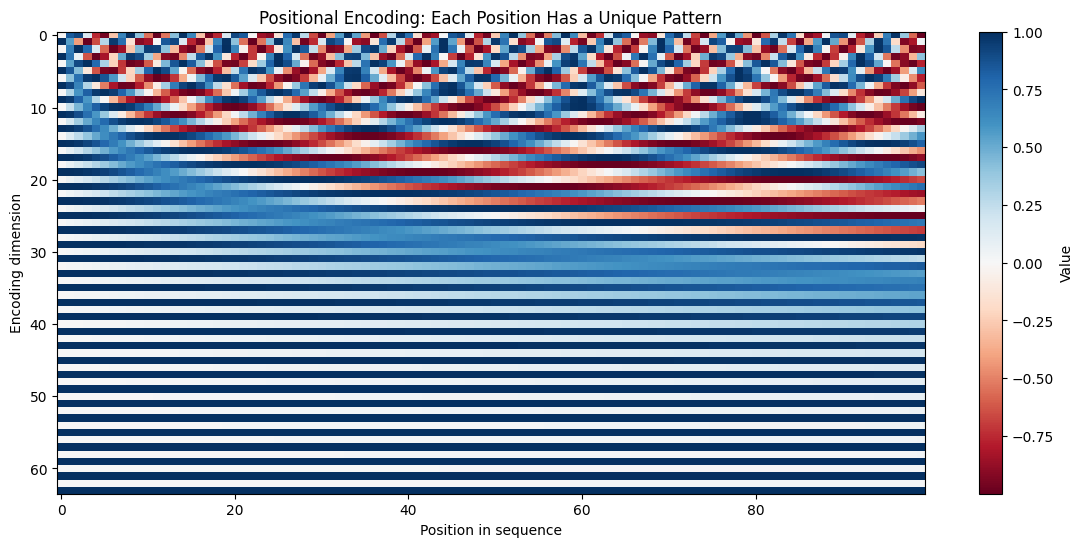

In [9]:
# Visualize the positional encodings

plt.figure(figsize=(14, 6))
plt.imshow(pe.T, aspect='auto', cmap='RdBu')
plt.colorbar(label='Value')
plt.xlabel('Position in sequence')
plt.ylabel('Encoding dimension')
plt.title('Positional Encoding: Each Position Has a Unique Pattern')
plt.show()

each column is a positional encoding . Each row is a dimention 
notice : 
low dimention( bottom ) = low frequency waves (changes slowly)

high dimention( top ) = high frequency waves (changes quickly)

each position has a unique pattern 



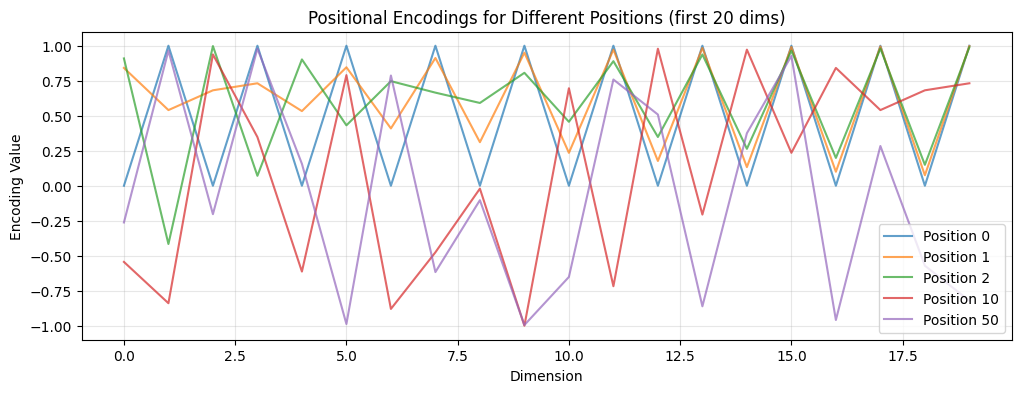

In [10]:
# Look at individual positions

positions_to_show = [0, 1, 2, 10, 50]

plt.figure(figsize=(12, 4))
for pos in positions_to_show:
    plt.plot(pe[pos, :20], label=f'Position {pos}', alpha=0.7)

plt.xlabel('Dimension')
plt.ylabel('Encoding Value')
plt.title('Positional Encodings for Different Positions (first 20 dims)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:


# Let's use a simple sentence
text = "The cat sat"
tokens = tokenizer.encode(text)
print(f"Text: '{text}'")
print(f"Tokens: {tokens}")

# Step 1: Get embeddings (using our random matrix from before)
d_model = 768
embedding_matrix = np.random.randn(50000, d_model) * 0.02
embeddings = np.array([embedding_matrix[t] for t in tokens])
print(f"\nEmbeddings shape: {embeddings.shape}")  # (3, 768)

# Step 2: Get positional encodings
pe = get_positional_encoding(len(tokens), d_model)
print(f"Positional encodings shape: {pe.shape}")  # (3, 768)

# Step 3: ADD them together
final_embeddings = embeddings + pe
print(f"Final embeddings shape: {final_embeddings.shape}")  # (3, 768)

print("\nNow each token's representation includes BOTH meaning AND position!")

Text: 'The cat sat'
Tokens: [791, 8415, 7731]

Embeddings shape: (3, 768)
Positional encodings shape: (3, 768)
Final embeddings shape: (3, 768)

Now each token's representation includes BOTH meaning AND position!


In [13]:
# Verify: same word at different positions has different representation

# "the" at position 0
the_pos0 = embedding_matrix[tokenizer.encode("the")[0]] + get_positional_encoding(1, d_model)[0]

# "the" at position 5 (simulated)
the_pos5 = embedding_matrix[tokenizer.encode("the")[0]] + get_positional_encoding(6, d_model)[5]

# How different are they?
difference = np.linalg.norm(the_pos0 - the_pos5)
print(f"Same word 'the' at position 0 vs position 5:")
print(f"  Euclidean distance: {difference:.4f}")
print(f"\nThe same word has DIFFERENT representations at different positions!")

Same word 'the' at position 0 vs position 5:
  Euclidean distance: 14.1023

The same word has DIFFERENT representations at different positions!


 Checkpoint: Positional Encoding Complete

You now understand:
- Why position matters (word order changes meaning)
- Sine/cosine waves create unique position patterns
- Position encoding ADDS to embeddings
- Same word at different positions → different representation

